# E-Commerce Sales Analysis

# Introduction

This project analyzes two years of online retail transactions to identify sales trends, customer purchasing behavior, and opportunities for business improvement using Pandas and Seaborn.

## Objectives

The primary objectives of this analysis are to:

- Explore sales trends over time
- Identify the best-selling and highest-revenue products
- Analyze customer purchasing behavior
- Compare sales performance across countries
- Investigate transaction cancellations and returns
- Provide data-driven business recommendations

## Tools

The tools this project will use are:
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

## Dataset 

The Online Retail II data set contains all the transactions occurring for a UK-based and registered, non-store online retailer between 01/12/2009 and 09/12/2011 and contains more the 1 million entries. This dataset was made available through the UC Irvine Machine Learning Repository and was donated to them on 9/20/2019. The dataset's description says the company mainly sells unique all-occasion giftware and that many customers of the company are wholesalers.

The dataset is licensed under a Creative Commons Attribution 4.0 International license. This allows for the sharing and adaptation of the datasets for any purpose, provided that the appropriate credit is given.

## Column Description

UCI have provided the description of each column as follows:
* **Invoice**: Invoice number. Nominal. A 6-digit integral number uniquely assigned to each transaction. If this code starts with the letter 'c', it indicates a cancellation. 
* **StockCode**: Product (item) code. Nominal. A 5-digit integral number uniquely assigned to each distinct product. 
* **Description**: Product (item) name. Nominal. 
* **Quantity**: The quantities of each product (item) per transaction. Numeric.	
* **InvoiceDate**: Invoice date and time. Numeric. The day and time when a transaction was generated. 
* **UnitPrice**: Unit price. Numeric. Product price per unit in sterling (Â£). 
* **CustomerID**: Customer number. Nominal. A 5-digit integral number uniquely assigned to each customer. 
* **Country**: Country name. Nominal. The name of the country where a customer resides.

# Processing

## Loading the data

In [40]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

data2009 = pd.read_csv("C:/Users/takia/Downloads/Online Retail II Project/Online Retail II Dataset/online_retail_data_2009.csv")
data2010 = pd.read_csv("C:/Users/takia/Downloads/Online Retail II Project/Online Retail II Dataset/online_retail_data_2010.csv")
retail_data = pd.concat([data2009, data2010], ignore_index=True)

## Data Overview

In [41]:
retail_data.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,12/1/2009 7:45,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,12/1/2009 7:45,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,12/1/2009 7:45,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,12/1/2009 7:45,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,12/1/2009 7:45,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,12/1/2009 7:45,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,12/1/2009 7:45,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,12/1/2009 7:45,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,12/1/2009 7:46,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,12/1/2009 7:46,3.75,13085.0,United Kingdom


In [42]:
# Check types and number of rows and columns

rows = len(retail_data)
retail_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


## Data Cleaning

### Duplicates

First, I checked how many duplicate rows there were and dropped them. 34335 duplicate rows were dropped.

In [43]:
print(retail_data.duplicated().sum())
retail_data = retail_data.drop_duplicates()

34335


### Nulls and misformed data

When I looked over the data set in Excel, I noticed some of the entries in the Description column were missing, had question marks, or did not match the all uppercase item name format the majority of the entries had.

In [44]:
retail_data.isna().sum()

Invoice             0
StockCode           0
Description      4275
Quantity            0
InvoiceDate         0
Price               0
Customer ID    235151
Country             0
dtype: int64

There are only nulls in the Descriptions and Customer ID columns, but I will ignore the nulls in the Customer ID column because I will not be doing any customer-based analysis.

As for the Description nulls, I will first try to fix some of the nulls by using the Stock Code and matching it to other entries and their item name in the description column. First, I made a map with known item names for each stock code from the entries that matched the common description format. Then, I used the map to fill in the empty or misformed columns.

In [45]:
# Store item name for each stock code (used later to fill in description blanks)

item_names = {}
for _, row in retail_data.iterrows():
    name = row["Description"]
    if (
        row["StockCode"] not in item_names
        and pd.notna(name)
        and "?" not in name
        and name.isupper()
    ):
        item_names[row["StockCode"]] = name

In [46]:
# Fill blank item names (Description Column) using stock codes

mask = (
    retail_data["Description"].isna() |
    retail_data["Description"].str.contains("\?", na=False)
)

retail_data.loc[mask, "Description"] = retail_data.loc[mask, "StockCode"].map(item_names)

In [47]:
# Drop the remaining nulls that couldn't be fixed

retail_data = retail_data.dropna(subset=["Description"])
retail_data.isna().sum()

Invoice             0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
Price               0
Customer ID    234739
Country             0
dtype: int64

### Remove negative quantities, free items, and adjustments

There are some entries with negative values. The ones with Invoice numbers starting with C indicate cancellations, and the others seem to clerical errors or adjustments or damaged/missing products. Since I don't have access to the company's other finances, the financial adjustments are not relevant to my analysis, so I will drop them by dropping descriptions that are lowercase after the first letter, which doesn't fit the all uppercase item names. I will also drop negative quantities from the main dataset, but I will keep the cancellations in a different dataset.

In [48]:
# Check how many negative quantities

len(retail_data[retail_data["Quantity"] < 0])

22175

In [49]:
# Make separate dataset for cancelled transactions and remove negative/non-item quantities from main dataset

cancelled_transactions = retail_data[retail_data["Invoice"].astype(str).str.startswith("C")]
retail_data = retail_data[~retail_data["Description"].astype(str).str[1].str.islower()]
retail_data = retail_data[~retail_data["Description"].astype(str).str.contains("amazon", case=False, na=False)]
retail_data = retail_data[retail_data["Quantity"] > 0]

cancelled_transactions.describe()

,Quantity,Price,Customer ID
count,19104.000000,19104.000000,18390.000000
mean,-24.959119,42.849236,15007.871180
std,810.409329,574.810767,1699.925192
min,-80995.000000,0.010000,12346.000000
25%,-6.000000,1.450000,13534.000000
50%,-2.000000,2.950000,14902.000000
75%,-1.000000,6.650000,16401.000000
max,1.000000,38970.000000,18287.000000


Transactions with a unit price of £0 were removed because they do not represent revenue generating sales. These entries are likely promotional items, replacements, or data anomalies and would otherwise distort analyses involving sales and revenue.

In [50]:
# Only keep items with a price greater than $0

retail_data = retail_data[retail_data["Price"] > 0]

In [51]:
# Check how many rows were dropped in total

rows - len(retail_data)

60590

In total, 60,591 out of 1,067,371 rows were dropped due to duplicate, null, negative, and non-sale entries.

### Fix column types

I will change the type of the Invoice Date column from Object to DateTime to do time-based analysis.

In [52]:
# Change InvoiceDate column to datetime

retail_data["InvoiceDate"] = pd.to_datetime(retail_data["InvoiceDate"])

retail_data = retail_data.reset_index(drop=True)

I will also change the Customer ID column from a float to an integer.

In [53]:
# Change CustomerID column to Int32

retail_data["Customer ID"] = retail_data['Customer ID'].astype('Int32')

retail_data = retail_data.reset_index(drop=True)
retail_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1006781 entries, 0 to 1006780
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1006781 non-null  object        
 1   StockCode    1006781 non-null  object        
 2   Description  1006781 non-null  object        
 3   Quantity     1006781 non-null  int64         
 4   InvoiceDate  1006781 non-null  datetime64[ns]
 5   Price        1006781 non-null  float64       
 6   Customer ID  778583 non-null   Int32         
 7   Country      1006781 non-null  object        
dtypes: Int32(1), datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 58.6+ MB


### Adding a total price column

I will add a column called TotalPrice for the total price of each transaction, which will be calculated by multiplying the quantity with the unit price. I will also change the Price column's name to UnitPrice to differentiate and I will change the Customer ID column to CustomerID to be consistent with the rest of the column names.

In [54]:
# Create TotalPrice column

retail_data["TotalPrice"] = retail_data["Price"] * retail_data["Quantity"]

# Rename columns

retail_data.rename(columns={'Customer ID': 'CustomerID'}, inplace=True)
retail_data.rename(columns={'Price': 'UnitPrice'}, inplace=True)

### Add a month and year column

I will add a month and year column for convenience.

In [55]:
# Add a month and year from datetime column

retail_data["Year"] = retail_data["InvoiceDate"].dt.year
retail_data["Month"] = retail_data["InvoiceDate"].dt.month_name()

month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

# Creates ordered categories for the months

retail_data["Month"] = pd.Categorical(
    retail_data["Month"],
    categories=month_order,
    ordered=True
)

### Add a category column

Finally, I will add a column called Category that assigns a category to each item based on keywords in the item name in the Description column. 

The categories are:
* Outdoors
* Kitchen & Dinner
* Party
* Holidays
* Bath & Beauty
* Accessories
* Home & Business
* Household Essentials
* Storage
* Kids & Toys
* School & Work
* Other

The keyword lists were refined through multiple iterations to improve the accuracy of the category assignments. I examined different portions of the dataset, tailored the keywords to common products, and reviewed each category by sorting products in descending order of frequency to verify that the majority of items were classified appropriately.

Because the categories are assigned automatically using keyword matching, rather than manual review, some products may still be assigned to an incorrect category. Given the size of the dataset, manually verifying every product was not practical. Therefore, the category assignments should be considered a reasonable approximation rather than a perfect classification.

In [56]:
# Lists of keywords for each category

category_keywords = {
    "Outdoors": [
        "WIND", "GARDEN ", "TROWEL", "SHOVEL", "PLANT", "PLANTER", "SEED", "CAGE", "FEEDER", "OUTDOOR", "PICNIC", "BEACH", "SUN ", "SUMMER", 
        "CAMP ", "LANTERN", "WATERING", "BUCKET", "HOSE", "HAMMOCK", "PARASOL", "SAND", "WATER BASIN", "TORCH", "GNOME", "RAIN", "GROW",
        "BIRDHOUSE", "PAIL", "HERB"
    ],
    "Party": [
        "PARTY", "BALLOON", "BIRTHDAY", "CELEBRATION", "CAKE", "STREAMER", "CONFETTI", "INVIT", "RIBBON", "BUNTING"
    ],
    "Holidays": [
        "CHRISTMAS", "XMAS", "SANTA", "REINDEER", "SNOW", "ORNAMENT", "CARD", "WREATH", "GIFT", "WRAP", "GARLAND",
        "EASTER", "HALLOWEEN", "CREEPY", "HARE", "EGG", "COSTUME", "HOLIDAY"
    ],
    "Bath & Beauty": [
        "BEAUTY", "COSMETIC", "MAKEUP", "LIP", "NAIL", "MASCARA", "EYE", "LASH", "FACE", "CREAM", "LOTION", "MOISTUR", "PERFUME", "HAIR",
        "FRAGRANCE", "SCENT", "POWDER","BLUSH", "BRUSH", "VANITY", "CONCEALER", "FOUNDATION", "PRIMER", "PALETTE", "LINER", "GLOSS", "SERUM",
        "SHAMPOO", "CONDITIONER", "SCRUB", "LOOFA", "SOAP", "OIL", "COMB", "BRUSH", "JEWELLERY", "TOOTH", "BALM" 
    ],
    "Accessories": [
        "NECKLACE", "BRACELET", "EARRING", "JEWELRY", " HAT", "PURSE", "SOMBRERO", "CHAIN", "CHARM", " RING", "BROOCH", "LANYARD", " PIN ",
        "PENDANT", "WATCH", "BADGE", " BEAD", "CLIP", "HEADPHONES"
    ],
    "School & Work": [
        "LUNCH", "BACKPACK", "PENCIL", " PEN", "BOOK", "SCISSOR", "GLUE", "STAPLE", "NOTE", " BOARD", "CRAYON", "MARKER", "BOTTLE", 
        "HIGHLIGHTER", "CHALK", " TAPE", "TUMBLER", "STATIONERY", "JOURNAL", "CALC", "BEAKER", "ERASER"
    ],
    "Home & Business Decor": [
        "CANDLE", "FRAME", "HEART", "VASE", "PICTURE", "WORD", "FEATHER", "NUMBER TILE", "FILIGREE",
        "HOME", "GLOBE", "DOORMAT", "DECO", "LETTER", " ART", "DOVE", "STAR ", " SIGN", "HANGING", "PHOTO", "CHANDELIER"
    ],
    "Kids & Toys": [
        "TOY", "DOLL", "TEDDY", "PUZZLE", "GAME", "SNAKES & LADDERS", "ALPHABET", "BOY", "GIRL", "BINGO", "CHILD", "SOLDIER", "CHESS", "NIGHT LIGHT",
        "HELICOPTER", "STUFFED", "BUNNY", "STICKER", "CRAFT", "CLAY", "PAINT", " TOP", "PIGGY", "PLAY", "BLOCKS", "TREASURE", "PIRATE", "BABY",
        "BALL", "DISC", "DUCK", "MAGIC", "DRAWING", "SLATE", "MOBILE", "ANIMAL", "FROG", "DINOSAUR", "BUNNIES", " HEN", "BEAR", "JIGSAW", "MONSTER"
    ],
    "Kitchen & Dinner": [
        "MUG", "CUP", "GLASS", "TEA", "COFFEE", "PLATE", "BOWL", "SPOON", "FORK", "KNIFE", "JUG", "BAKING", "COOK", "KITCHEN", "BREAD", " ICE",
        "COASTER", "PAN", "WINE", "PANTRY", "APRON", "FOOD", "CUT", "JAR", " POT", "OVEN", "DINER", "DISH", 
        "TONG", "CONTAINER", "PLATTER", "JAM", "SALAD", "SERVER", "DESSERT", "CHOP", "SUGAR" 
    ],
    "Storage": [
        "BOX", "BASKET", " TIN" "STORAGE", "CARRY", "SHOPPER", "CASE", "CRATE", " BIN", "LUGGAGE", "BAG"
    ],
    "Household Essentials": [
        "UMBRELLA", "CABINET", "HOOK", "HANGER", "RACK", "SHELF", "ORGANIZER", "HOLDER", "TRAY", "CLOCK", "SWAT", "NAPKIN", "SEAT",
        "CUSHION", "DRAWER", "LIGHT", "DOOR", "TISSUE", "PAPER TOWEL", "SEWING", "ENVELOPE", "KEY", "TABLE", "CALENDAR", "HOME",
        "THERMOMETER", "FAN", "MIRROR", "POUFFE", "REPAIR", "STRAW", "MAGNET", "PEG", "LAMP", "FIRST AID", "INCENSE", 
        "BATH", "SHOWER", "TOWEL", "WASH", "FLANNEL", "SPONGE", "TOILET", "STAND", "WARMER", "CURTAIN", "SCREW", "QUILT"
    ]
}

def assign_category(description):
    if pd.isna(description):
        return "Unknown"

    description = description.upper()

    for category, keywords in category_keywords.items():
        for keyword in keywords:
            if keyword in description:
                return category

    return "Other"

# Apply runs assign_category once for every value in the Description column Series
retail_data["Category"] = retail_data["Description"].apply(assign_category)

### Anomolies

During the data cleaning process, I identified an unusual transaction involving the product PICNIC BASKET WICKER SMALL (StockCode 22502) purchased by Customer 15098.

The transaction contains a unit price of £649.50 and a quantity of 1, but the custom description indicates the order has 60 pieces, so £649.50 appears to represent the total price for 60 items rather than the price of a single item. A second entry then records a quantity of 60 using this same unit price of £649.50, effectively treating the bundle price as the price per individual unit. This results in a total of 60 × 60 = 3,600 items and an unrealistically large transaction value.

This transaction is inconsistent with the pricing of the same product elsewhere in the dataset. Dividing £649.50 by 60 gives £10.825, which closely matches the product's common unit price of £10.79. Based on this evidence, I treated the transaction as a data entry anomaly by removing the duplicated custom entry and retaining a single transaction with a quantity of 60 priced consistently with the rest of the dataset.

Because this correction is based on inference rather than documented business rules, it should be considered a data cleaning assumption made to prevent a single anomalous transaction from disproportionately influencing the analysis.

In [57]:
# View erroneous entries

retail_data[retail_data["StockCode"] == "22502"].sort_values(by="UnitPrice", ascending=False).head(5)

,Invoice,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Year,Month,Category
697644,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,2011-06-10 15:28:00,649.50,15098,United Kingdom,38970.00,2011,June,Outdoors
697654,556446,22502,PICNIC BASKET WICKER 60 PIECES,1,2011-06-10 15:33:00,649.50,15098,United Kingdom,649.50,2011,June,Outdoors
592678,546007,22502,PICNIC BASKET WICKER SMALL,1,2011-03-08 15:34:00,10.79,<NA>,United Kingdom,10.79,2011,March,Outdoors
724709,559041,22502,PICNIC BASKET WICKER SMALL,1,2011-07-05 15:33:00,10.79,<NA>,United Kingdom,10.79,2011,July,Outdoors
694276,556087,22502,PICNIC BASKET WICKER SMALL,1,2011-06-08 15:24:00,10.79,<NA>,United Kingdom,10.79,2011,June,Outdoors


In [58]:
# Fix erroneous entries

row_to_drop = retail_data[(retail_data["Description"] == "PICNIC BASKET WICKER 60 PIECES") & (retail_data["TotalPrice"] == 38970.00)].index
retail_data.drop(row_to_drop, inplace=True)

row_to_change = retail_data[retail_data["Description"] == "PICNIC BASKET WICKER 60 PIECES"].index
retail_data.loc[row_to_change, "Description"] = "PICNIC BASKET WICKER SMALL"
retail_data.loc[row_to_change, "UnitPrice"] = 10.79	
retail_data.loc[row_to_change, "Quantity"] = 60	

retail_data[retail_data["StockCode"] == "22502"].sort_values(by="UnitPrice", ascending=False).head(5)

,Invoice,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Year,Month,Category
592678,546007,22502,PICNIC BASKET WICKER SMALL,1,2011-03-08 15:34:00,10.79,<NA>,United Kingdom,10.79,2011,March,Outdoors
694380,556090,22502,PICNIC BASKET WICKER SMALL,1,2011-06-08 15:25:00,10.79,<NA>,United Kingdom,10.79,2011,June,Outdoors
684321,555150,22502,PICNIC BASKET WICKER SMALL,1,2011-05-31 15:53:00,10.79,<NA>,United Kingdom,10.79,2011,May,Outdoors
685172,555275,22502,PICNIC BASKET WICKER SMALL,1,2011-06-01 17:18:00,10.79,<NA>,United Kingdom,10.79,2011,June,Outdoors
685398,555276,22502,PICNIC BASKET WICKER SMALL,1,2011-06-01 17:28:00,10.79,<NA>,United Kingdom,10.79,2011,June,Outdoors


I also noticed that the product PAPER CRAFT , LITTLE BIRDIE (StockCode 23843) had an order with a quantity of 80,995. I also noticed that the invoice right after was a cancellation of that order (has the same quantity), which is now in the cancelled_transactions dataframe. Since, this is anamolous data and was cancelled I will drop the original entry.

In [59]:
# View erroneous entries

retail_data[retail_data["StockCode"] == "23843"]

,Invoice,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Year,Month,Category
1005306,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446,United Kingdom,168469.6,2011,December,Kids & Toys


In [60]:
cancelled_transactions[cancelled_transactions["StockCode"] == "23843"]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1065883,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,12/9/2011 9:27,2.08,16446.0,United Kingdom


In [61]:
# Fix erroneous entries

row_to_drop = retail_data[(retail_data["StockCode"] == "23843") & (retail_data["Quantity"] == 80995)].index
retail_data.drop(row_to_drop, inplace=True)

# Analysis

## Overview

In [62]:
retail_data[["Quantity", "UnitPrice", "TotalPrice"]].describe().round(2)

,Quantity,UnitPrice,TotalPrice
count,1006779.00,1006779.00,1006779.00
mean,11.04,3.70,19.75
std,100.02,16.44,102.03
min,1.00,0.00,0.00
25%,1.00,1.25,4.13
50%,4.00,2.10,10.08
75%,12.00,4.13,17.70
max,74215.00,8142.75,77183.60


The mean quantity is 11, which follows the information in the dataset description, that the main customers of the company are wholesalers who buy in bulk. The mean UnitPrice is £3.70 indicating the majority of the items in their catalog aren't large exprensive products.

## Most bought products

First, I sorted by the total number of orders for each item descending to identify the items with the most orders. I also summed TotalQuantity for each item to see if they were also bought in large quantities in addition to being bought often. 

I included a column for the average unit price to see if there was a correlation between orders and price, and I used the average because a lot of products had multiple unit prices, which might be due to different versions of the product or a change in pricing.

I sorted by order count instead of quantity to identify which items were being bought the most often, instead of in large quantities since usually small inexpensive items are bought in large quantities and isn't related to the product's popularity.

In [63]:
# Sort data by total orders for each item descending, and show total quantity pruchased

item_orders = retail_data.groupby(
    ["StockCode", "Description", "Category"]
).agg(
    OrderCount=("Invoice", "nunique"),
    AvgUnitPrice = ("UnitPrice", "mean"),
    TotalQuantity=("Quantity", "sum")
).reset_index().sort_values(
    by="OrderCount",
    ascending=False
).head(20)

item_orders["AvgUnitPrice"] = item_orders["AvgUnitPrice"].round(2)
item_orders.head(20)

,StockCode,Description,Category,OrderCount,AvgUnitPrice,TotalQuantity
4989,85123A,WHITE HANGING HEART T-LIGHT HOLDER,Home & Business Decor,5356,3.08,94142
1885,22423,REGENCY CAKESTAND 3 TIER,Party,3918,14.19,26478
4957,85099B,JUMBO BAG RED RETROSPOT,Storage,3245,2.37,77280
4630,84879,ASSORTED COLOUR BIRD ORNAMENT,Holidays,2807,1.86,80082
3706,47566,PARTY BUNTING,Party,2674,5.72,28200
289,20727,LUNCH BAG BLACK SKULL.,School & Work,2351,2.02,26678
1352,21931,JUMBO STORAGE BAG SUKI,Storage,2329,2.53,29182
692,21232,STRAWBERRY CERAMIC TRINKET BOX,Storage,2310,1.52,36628
1869,22411,JUMBO SHOPPER VINTAGE RED PAISLEY,Storage,2192,2.45,27281
1942,22469,HEART OF WICKER SMALL,Home & Business Decor,2151,1.92,27908


The store's 3 most bought products are tea light holder, cakestands, and storage bags. Cake-cases/stands, lunch bags, storage bags, and home decor apprear multiple times in the top 20 most bought items.

Then, I sorted by descending revenue for each item by summing the total price for every order of each product. I discluded categories of type Other because the only items that appeared from that category in the top 20 were postage fees.

In [64]:
# Sort data by revenue per item descending

item_revenue = retail_data.groupby(
    ["StockCode", "Description", "Category"]
).agg(
    OrderCount = ("Invoice", "nunique"),
    TotalQuantity = ("Quantity", "sum"),
    AvgUnitPrice = ("UnitPrice", "mean"),
    TotalRevenue = ("TotalPrice", "sum")
).reset_index().sort_values(
    by="TotalRevenue", ascending=False
)

item_revenue["AvgUnitPrice"] = item_revenue["AvgUnitPrice"].round(2)
item_revenue[item_revenue["Category"]!="Other"].head(20)

,StockCode,Description,Category,OrderCount,TotalQuantity,AvgUnitPrice,TotalRevenue
1885,22423,REGENCY CAKESTAND 3 TIER,Party,3918,26478,14.19,330590.32
4989,85123A,WHITE HANGING HEART T-LIGHT HOLDER,Home & Business Decor,5356,94142,3.08,257546.20
3706,47566,PARTY BUNTING,Party,2674,28200,5.72,148318.28
4957,85099B,JUMBO BAG RED RETROSPOT,Storage,3245,77280,2.37,145961.83
4630,84879,ASSORTED COLOUR BIRD ORNAMENT,Holidays,2807,80082,1.86,129324.49
1471,22086,PAPER CHAIN KIT 50'S CHRISTMAS,Holidays,2018,35084,3.37,117760.29
2803,23166,MEDIUM CERAMIC TOP STORAGE JAR,Kids & Toys,247,78033,1.47,81700.92
4048,79321,CHILLI LIGHTS,Household Essentials,1135,15841,6.29,80540.88
4217,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,Household Essentials,756,31409,3.34,71300.40
4961,85099F,JUMBO BAG STRAWBERRY,Storage,1830,36860,2.29,67985.77


The top 3 items with the most revenue were the cakestand, tea light holder, and party bunting. The cakestand is the most expensive of the top 20 at £14.19 and it also generated the most revenue, but a lower quantity (26,478) of it was sold than the rest of the items near the top (70,000-90,000). 

The rest of the items cost much less. Most items that generate a lot of revenue are in the £2-£6 range.

The lowest priced item in the top 20 list is the bird ornament at £1.47, but it sold a high quantity of 80,082 and generated £129,324.49 (5th most revenue generated). This a small inexpensive item, which is most likely why it was bought in high quantities.

In summary, party bunting, small lights, storage bags, and cake stands generated the most revenue.

I also wanted to see what the most expensive items were.

In [65]:
# Sort items by unit price

item_revenue[item_revenue["Category"]!="Other"].sort_values(by="AvgUnitPrice", ascending=False).head(20)

,StockCode,Description,Category,OrderCount,TotalQuantity,AvgUnitPrice,TotalRevenue
2159,22656,VINTAGE BLUE KITCHEN CABINET,Kitchen & Dinner,37,45,214.86,9290.00
2158,22655,VINTAGE RED KITCHEN CABINET,Kitchen & Dinner,53,76,186.32,12845.00
2365,22827,RUSTIC SEVENTEEN DRAWER SIDEBOARD,Household Essentials,29,38,158.79,5910.00
2364,22827,GIANT SEVENTEEN DRAWER SIDEBOARD,Household Essentials,6,8,158.33,1240.00
2366,22828,REGENCY MIRROR WITH SHUTTERS,Household Essentials,11,17,154.09,2565.00
2360,22823,CHEST NATURAL WOOD 20 DRAWERS,Household Essentials,18,32,117.50,3655.00
2363,22826,LOVE SEAT ANTIQUE WHITE METAL,Household Essentials,41,58,114.02,6210.00
4931,85070,ANT WHITE SWEETHEART TABLE W 3 DRAW,Home & Business Decor,3,3,106.67,320.00
1207,21769,VINTAGE POST OFFICE CABINET,Household Essentials,48,123,77.63,7954.87
4732,84967C,GREEN KASHMIRI OCCASIONAL TABLE,Household Essentials,4,9,67.46,419.85


It seems the most expensive items are furniture, however they don't sell that well and have low order counts. The best-selling furniture items are the two kitchen cabinets (VINTAGE BLUE KITCHEN CABINET and VINTAGE RED KITCHEN CABINET). They have relatively high order counts and total revenues of £9,290.00 and £12,845.00, respectively. They are also the most expensive items at £214.86 and £186.32.

## Orders by category

Next, I focused on the broader categories instead of specific items. I counted the number of orders for each category. Orders repeat across categories and are only unique within a category since orders have items from multiple categories.

In [66]:
# Find the number of orders for each category 

category_orders = (
    retail_data
    .groupby("Category")
    .agg({"Invoice": "nunique"})
    .rename(columns={"Invoice": "Order Count"})
    .reset_index()
    .sort_values(by="Order Count", ascending=False)
)
category_orders

,Category,Order Count
3,Home & Business Decor,27634
6,Kitchen & Dinner,24604
9,Party,23930
4,Household Essentials,23921
10,School & Work,21496
2,Holidays,21390
11,Storage,21138
5,Kids & Toys,20921
7,Other,16686
1,Bath & Beauty,16666


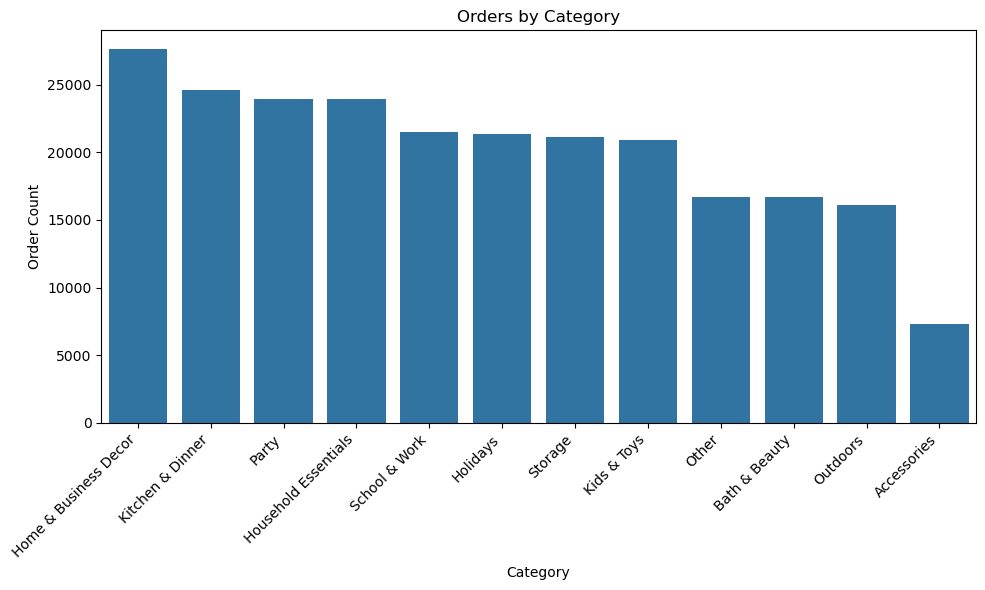

In [67]:
# Make bar graph for number of orders for each category

plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_orders,
    x="Category",
    y="Order Count"
)

plt.xticks(rotation=45, ha="right")
plt.title("Orders by Category")
plt.tight_layout()
plt.show()


Home & Business Decor had the most orders with 27,634 order. Kitchen & Dinner, Party, Household Essentials 2nd, 3rd, and 4th and are all very close, ranging from 23,000-25,000 orders. Accessories has the least orders.

In [68]:
# Find the revenue for each category

category_revenue = (
    retail_data
    .groupby("Category")
    .agg(
        OrderCount=("Invoice", "nunique"),
        TotalQuantity=("Quantity", "sum"),
        Revenue=("TotalPrice", "sum")
    ).reset_index()
    .sort_values(by="Revenue", ascending=False)
)

category_revenue

,Category,OrderCount,TotalQuantity,Revenue
3,Home & Business Decor,27634,1745239,3471185.110
6,Kitchen & Dinner,24604,1188932,2283997.360
9,Party,23930,1220016,2220084.200
4,Household Essentials,23921,1175000,2012940.157
11,Storage,21138,936727,1771995.020
10,School & Work,21496,1058909,1726516.030
5,Kids & Toys,20921,987671,1662109.070
2,Holidays,21390,1321247,1633822.480
7,Other,16686,426573,1115180.020
8,Outdoors,16132,434321,964660.810


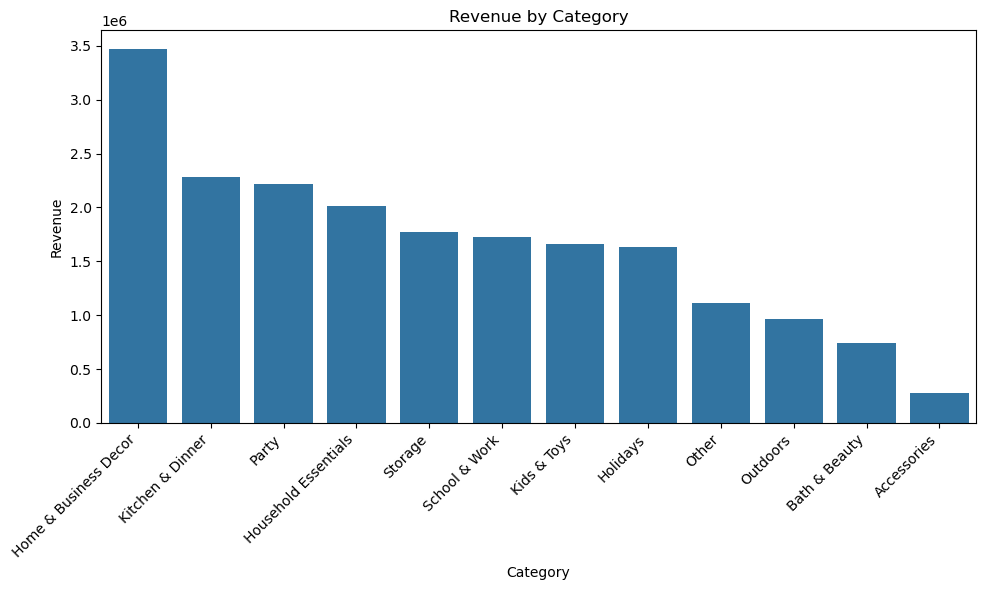

In [69]:
# Make bar graph for revenue for each category

plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_revenue,
    x="Category",
    y="Revenue" 
)
plt.xticks(rotation=45, ha="right")
plt.title("Revenue by Category")
plt.tight_layout()

plt.show()

The Revenue graph follows the the Orders graph and has almost the same order. However, the Home & Business Decor category has a much larger gap between it and the next category than the Orders graph. Home & Business Decor generated £3,471,185.11 and the next category Kitchen & Diner generated £2,283,997.36, which is more than 1 million more.

Then, I sorted the categories by how much revenue they generate on average per order. 

In [70]:
# Sort categories by highest revenue per order (orders repeat across different categories if order includes items from multiple categories)

temp = retail_data.groupby(["Category"]).agg(
    OrderCount = ("Invoice", "nunique"),
    TotalRevenue = ("TotalPrice", "sum")
).reset_index()
temp["Avg revenue per order"] = (temp["TotalRevenue"]/temp["OrderCount"]).round(2)
temp[temp["Category"]!="Other"].sort_values(by="Avg revenue per order", ascending=False)

,Category,OrderCount,TotalRevenue,Avg revenue per order
3,Home & Business Decor,27634,3471185.110,125.61
6,Kitchen & Dinner,24604,2283997.360,92.83
9,Party,23930,2220084.200,92.77
4,Household Essentials,23921,2012940.157,84.15
11,Storage,21138,1771995.020,83.83
10,School & Work,21496,1726516.030,80.32
5,Kids & Toys,20921,1662109.070,79.45
2,Holidays,21390,1633822.480,76.38
8,Outdoors,16132,964660.810,59.80
1,Bath & Beauty,16666,745822.610,44.75


I found that Home & Business Decor generates the most per order with £125.61 per order.

Then, I sorted by how much revenue each category generates on average per item.

In [78]:
# Sort categories by highest revenue per item sold

temp = retail_data.groupby(["Category"]).agg(
    ItemCount = ("Quantity", "sum"),
    TotalRevenue = ("TotalPrice", "sum"),
    AvgUnitPrice = ("UnitPrice", "mean")
).reset_index()
temp["Avg revenue per item"] = (temp["TotalRevenue"]/temp["ItemCount"]).round(2)
temp[temp["Category"]!="Other"].sort_values(by="Avg revenue per item", ascending=False)

,Category,ItemCount,TotalRevenue,AvgUnitPrice,Avg revenue per item
8,Outdoors,434321,964660.810,4.311158,2.22
3,Home & Business Decor,1745239,3471185.110,3.318849,1.99
6,Kitchen & Dinner,1188932,2283997.360,3.923574,1.92
11,Storage,936727,1771995.020,3.083322,1.89
1,Bath & Beauty,401222,745822.610,3.702187,1.86
9,Party,1220016,2220084.200,3.581678,1.82
4,Household Essentials,1175000,2012940.157,3.846009,1.71
5,Kids & Toys,987671,1662109.070,2.995842,1.68
10,School & Work,1058909,1726516.030,2.792008,1.63
0,Accessories,218142,275716.090,3.418815,1.26


The Outdoors category generates the most revenue per item sold on average. This is most likely due to the Outdoor items having higher unit prices

## Orders throughout the year

In this section, I analyzed orders thoughout the 2 year time period. First, I found the number of unique orders for each month in the 2 year time period.

In [108]:
# Number of (unique) orders for every month in the time period
# Make pivot table to seperate years

monthly_orders = retail_data.pivot_table(
    values="Invoice", 
    index="Month", 
    columns="Year", 
    aggfunc="nunique", 
    observed=True)
monthly_orders.loc["Yearly Total"] = monthly_orders.sum(axis=0)
monthly_orders["Monthly Total"] = monthly_orders.sum(axis=1)
monthly_orders

Year,2009,2010,2011,Monthly Total
Month,,,,
January,NaN,1054.0,1083.0,2137.0
February,NaN,1194.0,1094.0,2288.0
March,NaN,1653.0,1444.0,3097.0
April,NaN,1438.0,1238.0,2676.0
May,NaN,1487.0,1671.0,3158.0
June,NaN,1618.0,1528.0,3146.0
July,NaN,1513.0,1457.0,2970.0
August,NaN,1407.0,1355.0,2762.0
September,NaN,1798.0,1830.0,3628.0


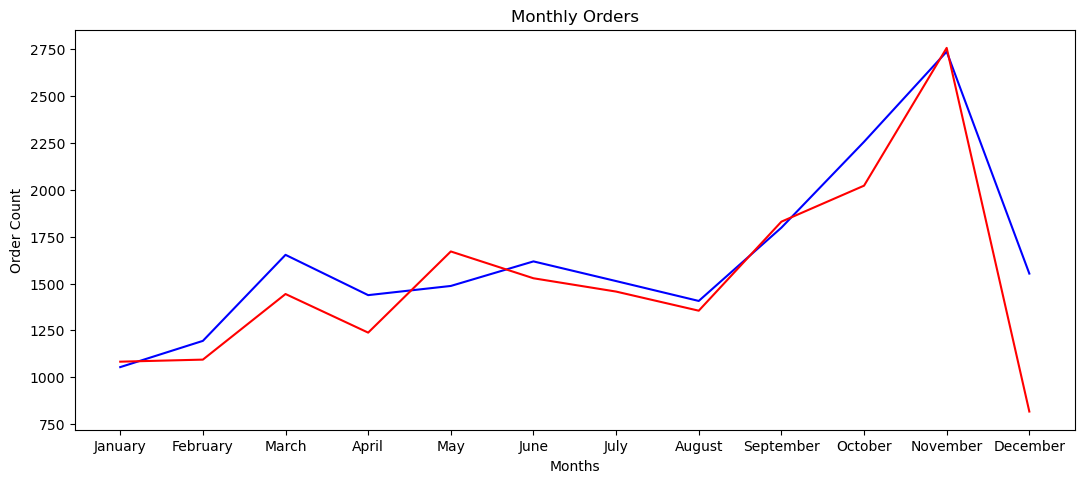

In [110]:
# Plot monthly orders (excluding totals)

fig1 = plt.figure(figsize=(10,4))
axes1 = fig1.add_axes([0,0,1,1])

monthly_orders.reset_index(inplace=True)

plt.title("Monthly Orders")
plt.xlabel("Months")
plt.ylabel("Order Count")

axes1.plot(monthly_orders["Month"].iloc[:-1], monthly_orders[2010].iloc[:-1], 'b')
axes1.plot(monthly_orders["Month"].iloc[:-1], monthly_orders[2011].iloc[:-1], 'r')

The highest number of orders are during September through November with 1,800-2,800 orders per month. The lowest months seems to be January and February with 1,000-1,200 orders per month. 2010 had more orders than 2011, by 1412 orders.

In [73]:
# Revenue for every month in the time period
# Make pivot table to seperate years

monthly_revenue = retail_data.pivot_table(
    values="TotalPrice", 
    index="Month", 
    columns="Year", 
    aggfunc="sum", 
    observed=True)
monthly_revenue.loc["Yearly Total"] = monthly_revenue.sum(axis=0)
monthly_revenue["Monthly Total"] = monthly_revenue.sum(axis=1)
monthly_revenue.round(2)

Year,2009,2010,2011,Monthly Total
Month,,,,
January,NaN,626477.93,689636.36,1316114.29
February,NaN,547288.18,521241.44,1068529.62
March,NaN,775988.09,707750.79,1483738.88
April,NaN,655268.88,526753.32,1182022.20
May,NaN,652350.99,763962.05,1416313.04
June,NaN,705515.93,716374.12,1421890.05
July,NaN,643217.21,706769.99,1349987.20
August,NaN,684122.77,743157.29,1427280.06
September,NaN,880520.13,1050205.00,1930725.13


The most revenue is generated between September and December, which range from £800,000 to £1,460,000 (December 2011 is cut off before the month ends so it has less). October and November have particularly high revenue, with more than 1 million pounds. January and Febuary have the least revenue.

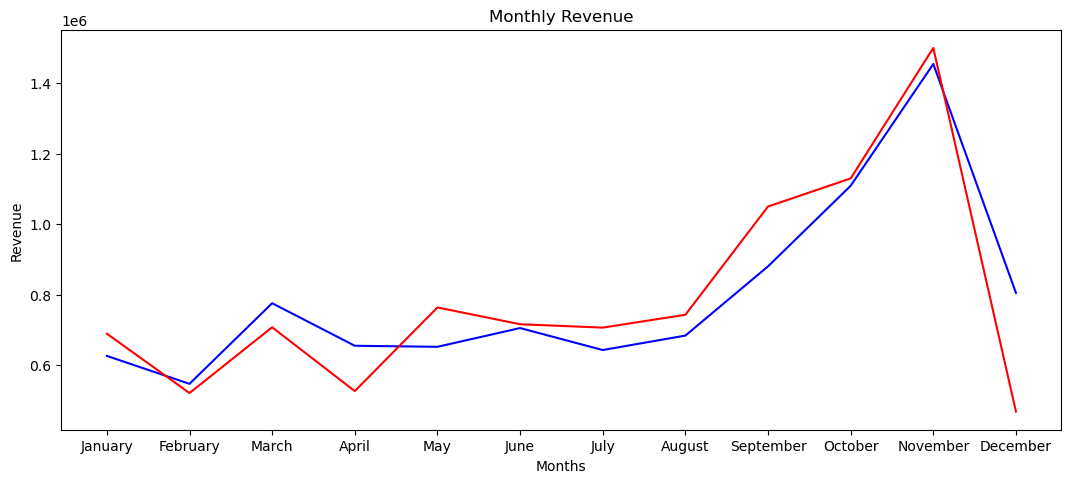

In [112]:
# Plot monthly revenue (excluding totals)

fig1 = plt.figure(figsize=(10,4))
axes1 = fig1.add_axes([0,0,1,1])

monthly_revenue.reset_index(inplace=True)

plt.title("Monthly Revenue")
plt.xlabel("Months")
plt.ylabel("Revenue")

axes1.plot(monthly_revenue["Month"].iloc[:-1], monthly_revenue[2010].iloc[:-1], 'b')
axes1.plot(monthly_revenue["Month"].iloc[:-1], monthly_revenue[2011].iloc[:-1], 'r')

In [74]:
# Find each category's order counts for each month

monthly_categories = retail_data.pivot_table(
    values="Invoice",
    index="Category",
    columns="Month",
    aggfunc="nunique",
    observed=True
)
monthly_categories

Month,January,February,March,April,May,June,July,August,September,October,November,December
Category,,,,,,,,,,,,
Accessories,428,425,597,527,476,576,516,474,646,823,967,827
Bath & Beauty,884,894,1232,1024,1366,1427,1305,1215,1573,1802,2380,1564
Holidays,1128,1192,1623,1228,1234,1250,1326,1427,2130,2838,3686,2328
Home & Business Decor,1614,1652,2148,1808,2098,2030,2020,1869,2535,3074,3930,2856
Household Essentials,1372,1398,1901,1646,1851,1888,1689,1547,2065,2656,3367,2541
Kids & Toys,1066,1206,1651,1417,1617,1619,1504,1447,1928,2346,3129,1991
Kitchen & Dinner,1410,1445,1992,1697,2005,1950,1873,1685,2194,2618,3307,2428
Other,873,968,1334,1198,1283,1375,1252,1135,1486,1838,2398,1546
Outdoors,930,952,1442,1467,1698,1637,1379,1068,1175,1336,1748,1300


In [75]:
# Find each category's revenue for each month

monthly_categories_revenue = retail_data.pivot_table(
    values="TotalPrice",
    index="Category",
    columns="Month",
    aggfunc="sum",
    observed=True
)
monthly_categories_revenue

Month,January,February,March,April,May,June,July,August,September,October,November,December
Category,,,,,,,,,,,,
Accessories,21186.320,15529.090,23403.300,22580.650,17198.94,22431.79,15821.840,18554.82,22584.220,26918.03,33196.410,36310.68
Bath & Beauty,39067.580,33927.110,50328.230,37248.160,61243.20,62458.67,56016.340,61411.32,73774.800,83725.28,114737.140,71884.78
Holidays,63556.820,63096.180,94193.100,58774.000,49052.67,53427.84,74309.180,98206.91,203115.520,285998.02,397681.370,192410.87
Home & Business Decor,243171.170,182478.880,235864.080,187283.930,232560.60,227432.51,254599.400,255458.95,357751.090,423743.14,495266.380,375574.98
Household Essentials,129980.202,122342.146,179985.241,129048.923,125370.91,128238.71,99540.341,109741.56,171960.692,228550.01,324203.542,263977.88
Kids & Toys,154249.930,76703.220,117276.940,90901.330,118228.37,108045.54,95414.400,118987.35,162859.170,201533.45,274088.560,143820.81
Kitchen & Dinner,181250.050,154756.360,183127.270,140430.960,183888.02,183025.37,184812.890,166160.93,224665.670,205251.24,261617.390,215011.21
Other,72463.110,65387.070,86228.940,64032.770,86171.72,79053.90,79006.770,74755.04,92180.660,110222.75,167956.970,137720.32
Outdoors,70169.630,53680.800,81832.720,99422.720,131858.41,114162.13,85131.920,56196.51,53832.040,63612.62,76757.810,78003.50


## Orders by location